# 🚢 Titanic Dataset – Exploratory Data Analysis & Feature Engineering  

## Objective:
To perform EDA on the Titanic dataset, extract insights, clean data, and transform it into a machine learning-ready format.

## 📦 Importing Libraries  

Importing required libraries for data analysis, visualization, and preprocessing.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
import seaborn as sns

## 📂 Dataset Loading  

Loading Titanic dataset and understanding structure.

In [14]:
df =pd.read_csv("Titanic-Dataset.csv")

## 🔍 Initial Data Exploration  

- Checking data types  
- Identifying missing values  
- Understanding statistical summary  

In [15]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### 🔍 Observation:
- Missing values present in Age and Cabin  
- Fare contains zero values (needs correction)  

## 🧹 Data Cleaning  

- Replacing Fare = 0 with median  
- Handling missing values in Age  

In [17]:
fare_median=df[df['Fare']!=0]['Fare'].median()
df['Fare'].replace(0,fare_median,inplace=True)

In [18]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.448316
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.569955
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,4.012500
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.925000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.500000
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 💰 Fare Analysis  

Analyzing how ticket price impacts survival.

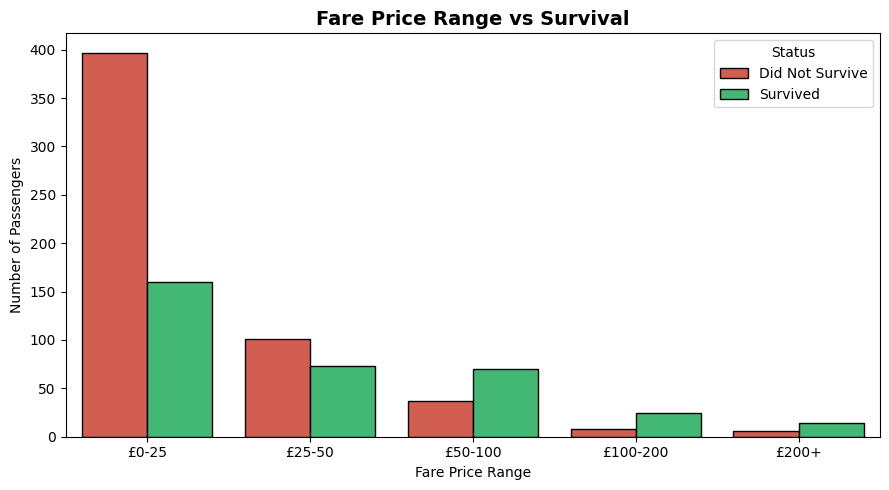

In [19]:
df['fare_range'] = pd.cut(df['Fare'], 
                           bins=[0, 25, 50, 100, 200, 600],
                           labels=['£0-25', '£25-50', '£50-100', '£100-200', '£200+'])

# ── Step 2: Plot ──────────────────────────────────────────
plt.figure(figsize=(9, 5))

sns.countplot(data=df, x='fare_range', hue='Survived',
              palette={0:'#e74c3c', 1:'#2ecc71'},
              edgecolor='black')

plt.title('Fare Price Range vs Survival', fontsize=14, fontweight='bold')
plt.xlabel('Fare Price Range')
plt.ylabel('Number of Passengers')
plt.legend(labels=['Did Not Survive', 'Survived'], title='Status')

plt.tight_layout()
plt.show()

### 🔍 Observation:
Higher fare passengers had significantly higher survival rates.

C:\Users\moizikha\AppData\Local\Temp\ipykernel_5196\812764676.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fare_survival = df.groupby('fare_range')['Survived'].mean() * 100


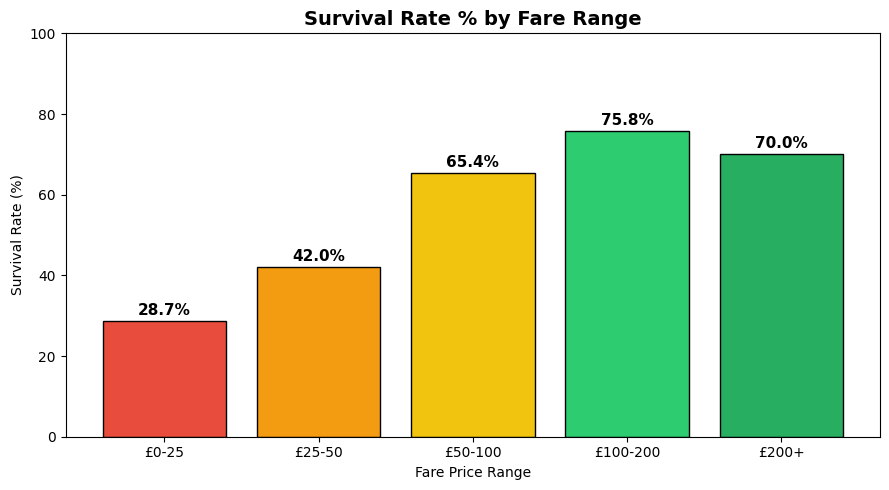

In [20]:
fare_survival = df.groupby('fare_range')['Survived'].mean() * 100

plt.figure(figsize=(9, 5))
bars = plt.bar(fare_survival.index, fare_survival.values,
               color=['#e74c3c','#f39c12','#f1c40f','#2ecc71','#27ae60'],
               edgecolor='black')

plt.title('Survival Rate % by Fare Range', fontsize=14, fontweight='bold')
plt.xlabel('Fare Price Range')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)

# Add % labels on top of each bar
for bar, val in zip(bars, fare_survival.values):
    plt.text(bar.get_x() + bar.get_width()/2, 
             val + 1.5, f'{val:.1f}%', 
             ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## 👨‍👩‍👧 Family Feature Analysis  

Analyzing SibSp and Parch impact on survival.

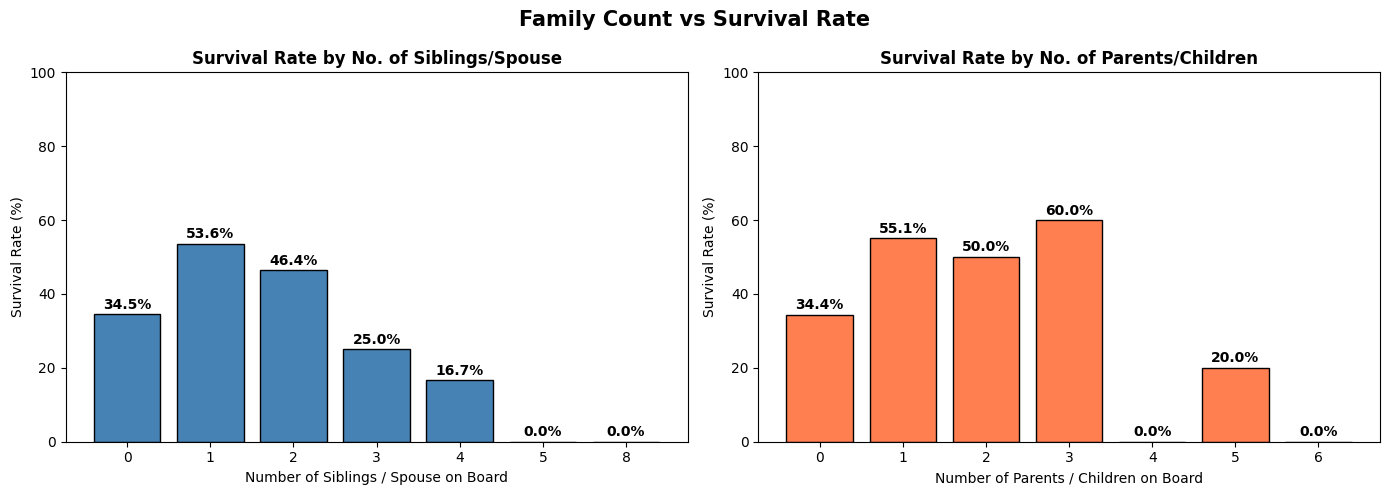

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: SibSp vs Survival Rate ────────────────────────
sibsp_survival = df.groupby('SibSp')['Survived'].mean() * 100

bars1 = axes[0].bar(sibsp_survival.index.astype(str), sibsp_survival.values,
                    color='steelblue', edgecolor='black')
axes[0].set_title('Survival Rate by No. of Siblings/Spouse',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Siblings / Spouse on Board')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_ylim(0, 100)

for bar, val in zip(bars1, sibsp_survival.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 1.5, f'{val:.1f}%',
                 ha='center', fontweight='bold', fontsize=10)

# ── Plot 2: Parch vs Survival Rate ────────────────────────
parch_survival = df.groupby('Parch')['Survived'].mean() * 100

bars2 = axes[1].bar(parch_survival.index.astype(str), parch_survival.values,
                    color='coral', edgecolor='black')
axes[1].set_title('Survival Rate by No. of Parents/Children',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Parents / Children on Board')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)

for bar, val in zip(bars2, parch_survival.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 1.5, f'{val:.1f}%',
                 ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Family Count vs Survival Rate', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 🔍 Observation:
- Moderate family size had higher survival chances  
- Very large families had lower survival rates  

## ⚙️ Feature Engineering – Family  

Creating:
- sibsp_favorable  
- parch_favorable  

In [22]:
# ── SibSp Category ────────────────────────────────────────
df['sibsp_favorable'] = df['SibSp'].apply(lambda x: 1 if x in [0, 1, 2] else 0)

# ── Parch Category ────────────────────────────────────────
df['parch_favorable'] = df['Parch'].apply(lambda x: 1 if x in [1, 2, 3] else 0)

# ── Verify ────────────────────────────────────────────────
print(df[['SibSp', 'sibsp_favorable', 'Parch', 'parch_favorable', 'Survived']].head(10))

   SibSp  sibsp_favorable  Parch  parch_favorable  Survived
0      1                1      0                0         0
1      1                1      0                0         1
2      0                1      0                0         1
3      1                1      0                0         1
4      0                1      0                0         0
5      0                1      0                0         0
6      0                1      0                0         0
7      3                0      1                1         0
8      0                1      2                1         1
9      1                1      0                0         1


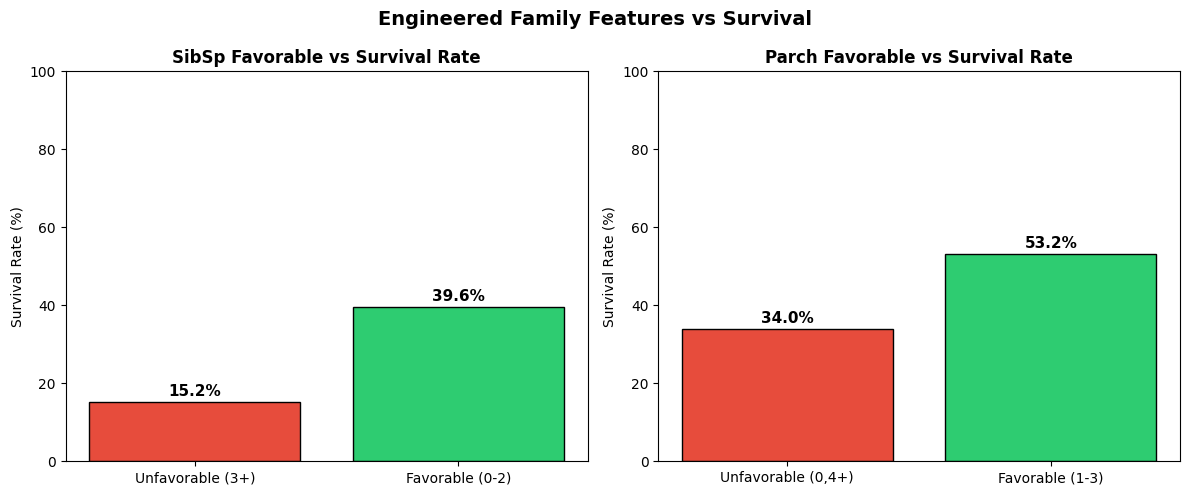

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# SibSp Favorable vs Survival
sibsp_val = df.groupby('sibsp_favorable')['Survived'].mean() * 100
bars1 = axes[0].bar(['Unfavorable (3+)', 'Favorable (0-2)'],
                     sibsp_val.values,
                     color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('SibSp Favorable vs Survival Rate',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars1, sibsp_val.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 1.5, f'{val:.1f}%',
                 ha='center', fontweight='bold', fontsize=11)

# Parch Favorable vs Survival
parch_val = df.groupby('parch_favorable')['Survived'].mean() * 100
bars2 = axes[1].bar(['Unfavorable (0,4+)', 'Favorable (1-3)'],
                     parch_val.values,
                     color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('Parch Favorable vs Survival Rate',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)
for bar, val in zip(bars2, parch_val.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 1.5, f'{val:.1f}%',
                 ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Engineered Family Features vs Survival',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🛳️ Cabin & Deck Analysis  

- Created has_cabin feature  
- Extracted deck from Cabin  

In [24]:
# ── has_cabin: 1 if cabin exists, 0 if missing ────────────
df['has_cabin'] = df['Cabin'].notnull().astype(int)

# ── deck: extract first letter, fill missing as 'Unknown' ─
df['deck'] = df['Cabin'].str[0].fillna('Unknown')

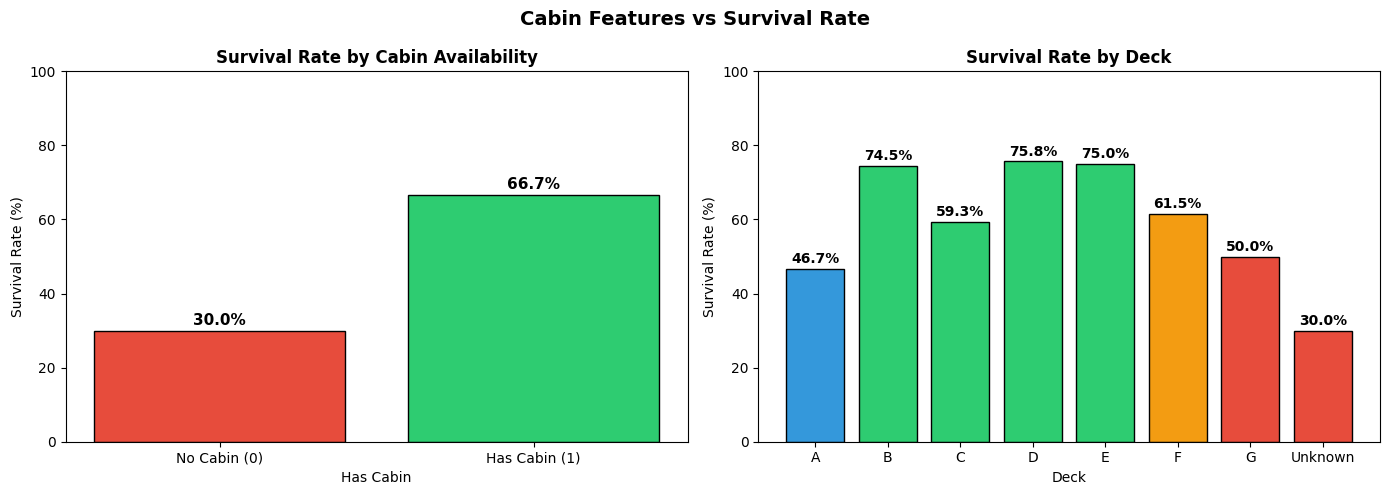

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: has_cabin vs Survival Rate ────────────────────
cabin_survival = df.groupby('has_cabin')['Survived'].mean() * 100

bars1 = axes[0].bar(['No Cabin (0)', 'Has Cabin (1)'],
                     cabin_survival.values,
                     color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Survival Rate by Cabin Availability',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Has Cabin')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_ylim(0, 100)

for bar, val in zip(bars1, cabin_survival.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 1.5, f'{val:.1f}%',
                 ha='center', fontweight='bold', fontsize=11)

# ── Plot 2: Deck vs Survival Rate ─────────────────────────
deck_order  = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'Unknown']
deck_survival = df.groupby('deck')['Survived'].mean() * 100
deck_survival = deck_survival.reindex(deck_order)

colors = ['#3498db','#2ecc71','#2ecc71','#2ecc71',
          '#2ecc71','#f39c12','#e74c3c','#e74c3c']

bars2 = axes[1].bar(deck_survival.index, deck_survival.values,
                     color=colors, edgecolor='black')
axes[1].set_title('Survival Rate by Deck',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Deck')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)

for bar, val in zip(bars2, deck_survival.values):
    if not pd.isna(val):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     val + 1.5, f'{val:.1f}%',
                     ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Cabin Features vs Survival Rate',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 🔍 Observation:
Passengers with cabin information had higher survival probability.

In [26]:
df['Age'].fillna(df['Age'].median(),inplace=True)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   PassengerId      891 non-null    int64   
 1   Survived         891 non-null    int64   
 2   Pclass           891 non-null    int64   
 3   Name             891 non-null    object  
 4   Sex              891 non-null    object  
 5   Age              891 non-null    float64 
 6   SibSp            891 non-null    int64   
 7   Parch            891 non-null    int64   
 8   Ticket           891 non-null    object  
 9   Fare             891 non-null    float64 
 10  Cabin            204 non-null    object  
 11  Embarked         889 non-null    object  
 12  fare_range       891 non-null    category
 13  sibsp_favorable  891 non-null    int64   
 14  parch_favorable  891 non-null    int64   
 15  has_cabin        891 non-null    int64   
 16  deck             891 non-null    object  
dt

C:\Users\moizikha\AppData\Local\Temp\ipykernel_5196\1730947996.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby('age_group')['Survived'].mean() * 100


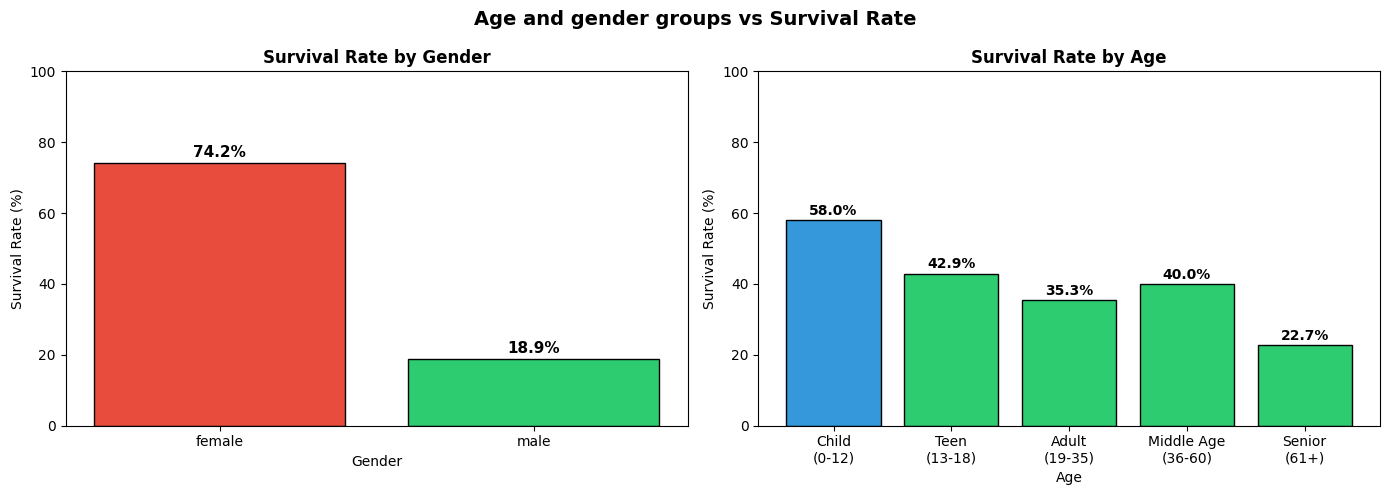

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: has_cabin vs Survival Rate ────────────────────
sex_survival = df.groupby('Sex')['Survived'].mean() * 100

bars1 = axes[0].bar(sex_survival.index,
                     sex_survival.values,
                     color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Survival Rate by Gender',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_ylim(0, 100)

for bar, val in zip(bars1, sex_survival.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 1.5, f'{val:.1f}%',
                 ha='center', fontweight='bold', fontsize=11)

# ── Plot 2: Deck vs Survival Rate ─────────────────────────
df['age_group'] = pd.cut(df['Age'],
                          bins=[0, 12, 18, 35, 60, 100],
                          labels=['Child\n(0-12)', 'Teen\n(13-18)', 
                                  'Adult\n(19-35)', 'Middle Age\n(36-60)', 
                                  'Senior\n(61+)'])
age_survival = df.groupby('age_group')['Survived'].mean() * 100


colors = ['#3498db','#2ecc71','#2ecc71','#2ecc71',
          '#2ecc71','#f39c12']

bars2 = axes[1].bar(age_survival.index, age_survival.values,
                     color=colors, edgecolor='black')
axes[1].set_title('Survival Rate by Age',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)

for bar, val in zip(bars2, age_survival.values):
    if not pd.isna(val):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     val + 1.5, f'{val:.1f}%',
                     ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Age and gender groups vs Survival Rate',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 🔍 Observation:
- Females had significantly higher survival rate  
- Children had higher survival probability  

In [29]:
df['sex_encoded'] = df['Sex'].map({'male': 0, 'female': 1})
df.drop(columns=['Sex'], inplace=True)

C:\Users\moizikha\AppData\Local\Temp\ipykernel_5196\1906324847.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
C:\Users\moizikha\AppData\Local\Temp\ipykernel_5196\1906324847.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
C:\Users\moizikha\AppData\Local\Temp\ipykernel_5196\1906324847.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(['Cherbourg (C)', 'Queenstown (Q)', 'Southampton (S)'])
C:\Users\moizikha\AppData\Local\Temp\ipykernel_5196\1906324847.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using

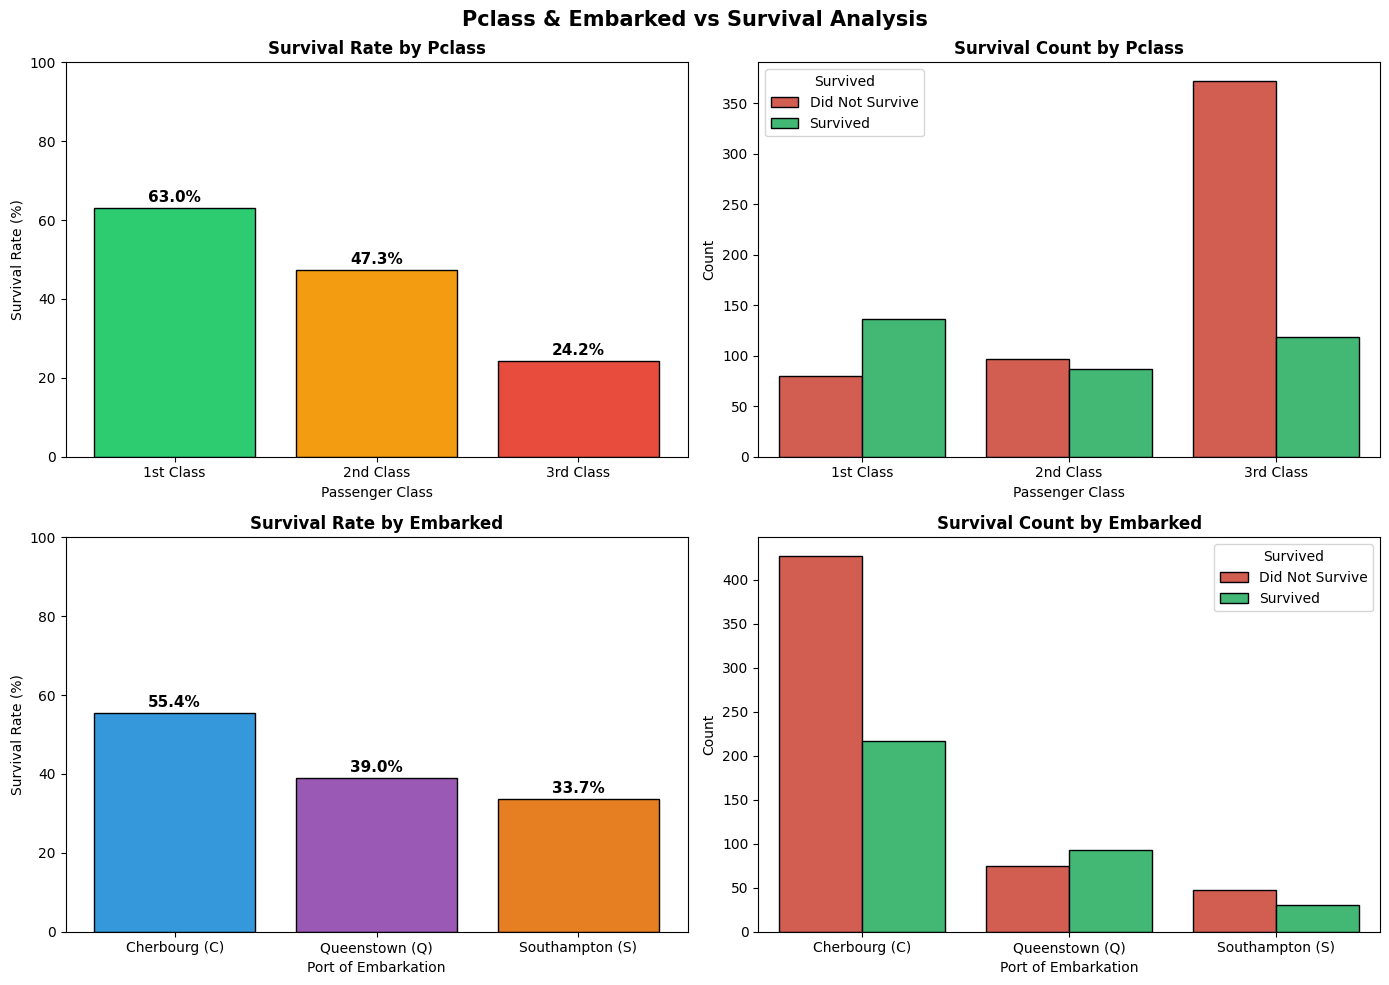

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Plot 1: Pclass Survival Rate % ────────────────────────
pclass_survival = df.groupby('Pclass')['Survived'].mean() * 100

bars1 = axes[0, 0].bar(pclass_survival.index.astype(str),
                        pclass_survival.values,
                        color=['#2ecc71', '#f39c12', '#e74c3c'],
                        edgecolor='black')
axes[0, 0].set_title('Survival Rate by Pclass', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Passenger Class')
axes[0, 0].set_ylabel('Survival Rate (%)')
axes[0, 0].set_ylim(0, 100)
axes[0, 0].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])

for bar, val in zip(bars1, pclass_survival.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2,
                    val + 1.5, f'{val:.1f}%',
                    ha='center', fontweight='bold', fontsize=11)

# ── Plot 2: Pclass Count with Survived/Not ────────────────
sns.countplot(data=df, x='Pclass', hue='Survived',
              palette={0:'#e74c3c', 1:'#2ecc71'},
              edgecolor='black', ax=axes[0, 1])
axes[0, 1].set_title('Survival Count by Pclass', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Passenger Class')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
axes[0, 1].legend(title='Survived', labels=['Did Not Survive', 'Survived'])

# ── Plot 3: Embarked Survival Rate % ──────────────────────
embarked_survival = df.groupby('Embarked')['Survived'].mean() * 100

bars3 = axes[1, 0].bar(embarked_survival.index,
                        embarked_survival.values,
                        color=['#3498db', '#9b59b6', '#e67e22'],
                        edgecolor='black')
axes[1, 0].set_title('Survival Rate by Embarked', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Port of Embarkation')
axes[1, 0].set_ylabel('Survival Rate (%)')
axes[1, 0].set_ylim(0, 100)
axes[1, 0].set_xticklabels(['Cherbourg (C)', 'Queenstown (Q)', 'Southampton (S)'])

for bar, val in zip(bars3, embarked_survival.values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2,
                    val + 1.5, f'{val:.1f}%',
                    ha='center', fontweight='bold', fontsize=11)

# ── Plot 4: Embarked Count with Survived/Not ──────────────
sns.countplot(data=df, x='Embarked', hue='Survived',
              palette={0:'#e74c3c', 1:'#2ecc71'},
              edgecolor='black', ax=axes[1, 1])
axes[1, 1].set_title('Survival Count by Embarked', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Port of Embarkation')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xticklabels(['Cherbourg (C)', 'Queenstown (Q)', 'Southampton (S)'])
axes[1, 1].legend(title='Survived', labels=['Did Not Survive', 'Survived'])

plt.suptitle('Pclass & Embarked vs Survival Analysis',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔄 Encoding Categorical Variables  

- Sex → Numerical  
- Pclass → Ordinal encoding  
- Embarked → Numerical encoding  
- Deck → Encoded values  

In [31]:
# ── Pclass Encoding ───────────────────────────────────────
pclass_mapping = {1: 3, 2: 2, 3: 1}
df['pclass_encoded'] = df['Pclass'].map(pclass_mapping)

# ── Embarked Encoding ─────────────────────────────────────
embarked_mapping = {'C': 3, 'Q': 2, 'S': 1}
df['embarked_encoded'] = df['Embarked'].map(embarked_mapping)

# ── Verify ────────────────────────────────────────────────
print(df[['Pclass', 'pclass_encoded', 'Embarked', 'embarked_encoded']].head(10))

   Pclass  pclass_encoded Embarked  embarked_encoded
0       3               1        S               1.0
1       1               3        C               3.0
2       3               1        S               1.0
3       1               3        S               1.0
4       3               1        S               1.0
5       3               1        Q               2.0
6       1               3        S               1.0
7       3               1        S               1.0
8       3               1        S               1.0
9       2               2        C               3.0


In [32]:
deck_mapping = {'B':7 , 'D': 6, 'E': 5,'F':4,'C':3,'G':2,'A':1,'Unknown':0}
df['deck_encoded'] = df['deck'].map(deck_mapping)


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   PassengerId       891 non-null    int64   
 1   Survived          891 non-null    int64   
 2   Pclass            891 non-null    int64   
 3   Name              891 non-null    object  
 4   Age               891 non-null    float64 
 5   SibSp             891 non-null    int64   
 6   Parch             891 non-null    int64   
 7   Ticket            891 non-null    object  
 8   Fare              891 non-null    float64 
 9   Cabin             204 non-null    object  
 10  Embarked          889 non-null    object  
 11  fare_range        891 non-null    category
 12  sibsp_favorable   891 non-null    int64   
 13  parch_favorable   891 non-null    int64   
 14  has_cabin         891 non-null    int64   
 15  deck              891 non-null    object  
 16  age_group         891 non-

In [34]:
df.drop(columns=['PassengerId','Pclass','Name','SibSp','Parch','Ticket','Cabin','Embarked','fare_range','deck'],inplace=True)

## 📏 Feature Scaling  

Standardizing numerical features:
- Age  
- Fare  

In [35]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df['fare_scaled'] = scaler.fit_transform(df[['Fare']])
df['age_scaled'] = scaler.fit_transform(df[['Age']])

In [40]:
df.drop(columns=['age_group'],inplace=True)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Survived          891 non-null    int64  
 1   sibsp_favorable   891 non-null    int64  
 2   parch_favorable   891 non-null    int64  
 3   has_cabin         891 non-null    int64  
 4   sex_encoded       891 non-null    int64  
 5   pclass_encoded    891 non-null    int64  
 6   embarked_encoded  889 non-null    float64
 7   deck_encoded      890 non-null    float64
 8   fare_scaled       891 non-null    float64
 9   age_scaled        891 non-null    float64
dtypes: float64(4), int64(6)
memory usage: 69.7 KB


## ✅ Final Dataset (ML Ready)  

- Removed irrelevant columns  
- Converted all features into numerical format  
- Dataset ready for machine learning models  

In [42]:
df.head(10)

,Survived,sibsp_favorable,parch_favorable,has_cabin,sex_encoded,pclass_encoded,embarked_encoded,deck_encoded,fare_scaled,age_scaled
0,0,1,0,0,0,1,1.0,0.0,-0.508624,-0.565736
1,1,1,0,1,1,3,3.0,3.0,0.783878,0.663861
2,1,1,0,0,1,1,1.0,0.0,-0.494999,-0.258337
3,1,1,0,1,1,3,1.0,3.0,0.416851,0.433312
4,0,1,0,0,0,1,1.0,0.0,-0.492476,0.433312
5,0,1,0,0,0,1,2.0,0.0,-0.484235,-0.104637
6,0,1,0,1,0,3,1.0,5.0,0.391872,1.893459
7,0,0,1,0,0,1,1.0,0.0,-0.229569,-2.102733
8,1,1,1,0,1,1,1.0,0.0,-0.430240,-0.181487
9,1,1,0,0,1,2,3.0,0.0,-0.047990,-1.180535


### 🔍 Final Insight:
EDA and feature engineering significantly improve model performance by transforming raw data into meaningful inputs.